<a href="https://colab.research.google.com/github/Abdallasherif/MNIST/blob/main/MNIST_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 MNIST Digit Classification with 4 ML Models.


---
🔍 Introduction:

This project compares four machine learning algorithms on the MNIST dataset of handwritten digits (0–9). The goal is to evaluate how each model performs on the same data using accuracy and confusion matrix as metrics.

The models used are:

K-Nearest Neighbors (KNN)

Support Vector Machine (SVM)

Linear Regression

K-Means Clustering

A final comparison will highlight the strengths and weaknesses of each.



> Abdalla Sherif Omar




# 📚 Import Libraries

In [ ]:
# Data Manipulation
import numpy as np
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Models & Tools
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from scipy.stats import mode

# Dataset Loader
import tensorflow as tf
from tensorflow.keras.datasets import mnist

# Model Saving
import joblib
import streamlit as st
from PIL import Image

# 🔃 Loading & Visualizing

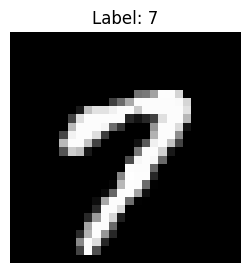

x_train shape: (60000, 28, 28)
y_train shape: (60000,)
x_test shape: (10000, 28, 28)
y_test shape: (10000,)


In [ ]:
# Load The MNIST Dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Sample Digit From the training Set
plt.figure(figsize=(3,3))
plt.imshow(x_train[15], cmap='gray')
plt.title(f"Label: {y_train[15]}")
plt.axis('off')
plt.show()

# Check the shape of data
print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

#  🔎 Preprocessing The Data

In [ ]:
# Flatten the 28*28 images into 1D Vectors
x_train = x_train.reshape(-1, 28*28)
x_test = x_test.reshape(-1, 28*28)

# Normalize the pixel values to be between 0 and 1
x_train = x_train / 255.0
x_test = x_test / 255.0

# convert labels from string to integers
y_train = y_train.astype(int)
y_test = y_test.astype(int)

# Shape after Preprocessing
print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

x_train shape: (60000, 784)
y_train shape: (60000,)
x_test shape: (10000, 784)
y_test shape: (10000,)


# 🏠 K-Nearest Neighbors (KNN)

KNN Accuracy: 0.9688

Confusion Matrix:

 [[ 974    1    1    0    0    1    2    1    0    0]
 [   0 1133    2    0    0    0    0    0    0    0]
 [  11    8  991    2    1    0    1   15    3    0]
 [   0    3    3  976    1   13    1    6    3    4]
 [   3    7    0    0  944    0    4    2    1   21]
 [   5    0    0   12    2  862    4    1    2    4]
 [   5    3    0    0    3    2  945    0    0    0]
 [   0   22    4    0    3    0    0  988    0   11]
 [   8    3    5   13    6   12    5    5  913    4]
 [   5    7    3    9    7    3    1   10    2  962]]

Classification Report:

               precision    recall  f1-score   support

           0       0.96      0.99      0.98       980
           1       0.95      1.00      0.98      1135
           2       0.98      0.96      0.97      1032
           3       0.96      0.97      0.97      1010
           4       0.98      0.96      0.97       982
           5       0.97      0.97      0.97       892
           6       0.9

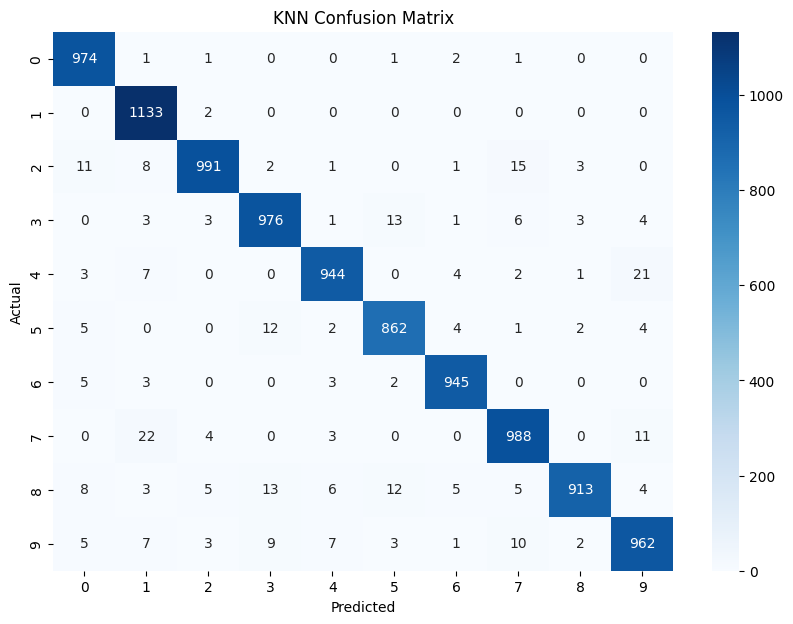

In [ ]:
# Test with K = 5
knn = KNeighborsClassifier(n_neighbors=5)

# Train the model
knn.fit(x_train, y_train)

# Predict
y_pred = knn.predict(x_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("KNN Accuracy:", accuracy)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n\n", cm)
newline = "\n"

# Report
report = classification_report(y_test, y_pred)
print("\nClassification Report:\n\n", report)
newline = "\n"

# Visualize
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('KNN Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 🤖 Support Vector Machine (SVM)

SVM Accuracy: 0.9404

Confusion Matrix:
 [[ 957    0    4    1    1    6    9    1    0    1]
 [   0 1122    3    2    0    1    2    1    4    0]
 [   8    6  967   11    3    3    7    8   17    2]
 [   4    3   16  947    1   16    0    9   12    2]
 [   1    1   10    1  942    2    4    2    3   16]
 [  10    4    3   36    6  803   13    1   14    2]
 [   9    2   13    1    5   16  910    1    1    0]
 [   1    8   21   10    8    1    0  957    3   19]
 [   8    4    6   25    7   26    6    7  877    8]
 [   7    7    2   11   33    4    0   18    5  922]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.98      0.96       980
           1       0.97      0.99      0.98      1135
           2       0.93      0.94      0.93      1032
           3       0.91      0.94      0.92      1010
           4       0.94      0.96      0.95       982
           5       0.91      0.90      0.91       892
           6       0.96 

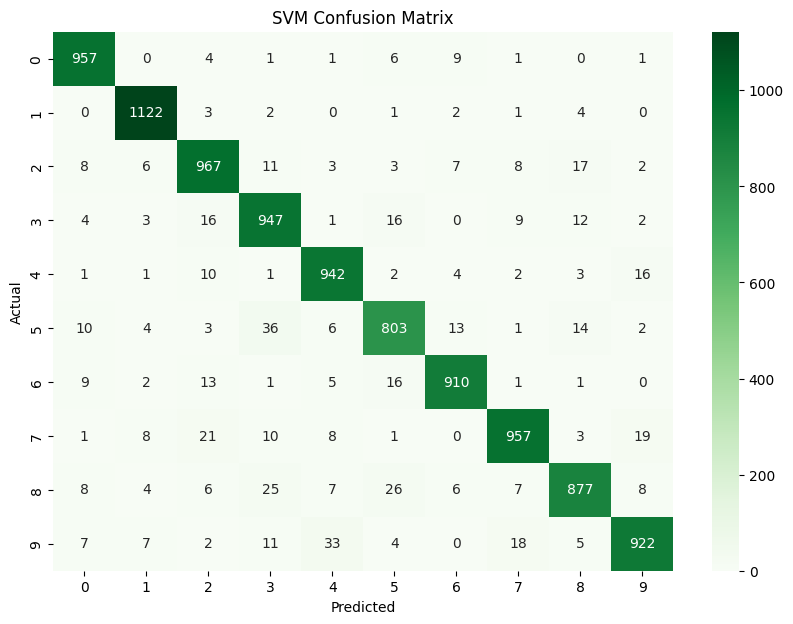

In [ ]:
# Create SVM Model
SVM = SVC(kernel='linear', random_state=42)

# Train the model
SVM.fit(x_train, y_train)

# Predict
y_pred = SVM.predict(x_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("SVM Accuracy:", accuracy)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

# Classification Report
report = classification_report(y_test, y_pred)
print("\nClassification Report:\n", report)

# Visualize Confusion Matrix
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title('SVM Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 📈 Linear Regression Model

LR Accuracy: 0.2303

Confusion Matrix:
 [[225 327 257 103  36  22   8   2   0   0]
 [  1 229 570 222  88  18   6   1   0   0]
 [ 38 123 244 305 216  84  18   1   3   0]
 [  7  43 196 325 273 100  42  12   9   3]
 [  0   0   5  36 197 338 249 115  39   3]
 [  0   3  21 118 253 288 143  36  19  11]
 [  2   4  24  73 158 265 270 117  43   2]
 [  0   1   6  26  74 141 241 283 159  97]
 [  0   1  10  27 100 189 277 229 103  38]
 [  0   1   4   9  25  58 142 312 319 139]]

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.23      0.36       980
           1       0.31      0.20      0.25      1135
           2       0.18      0.24      0.21      1032
           3       0.26      0.32      0.29      1010
           4       0.14      0.20      0.16       982
           5       0.19      0.32      0.24       892
           6       0.19      0.28      0.23       958
           7       0.26      0.28      0.26      1028
           8     

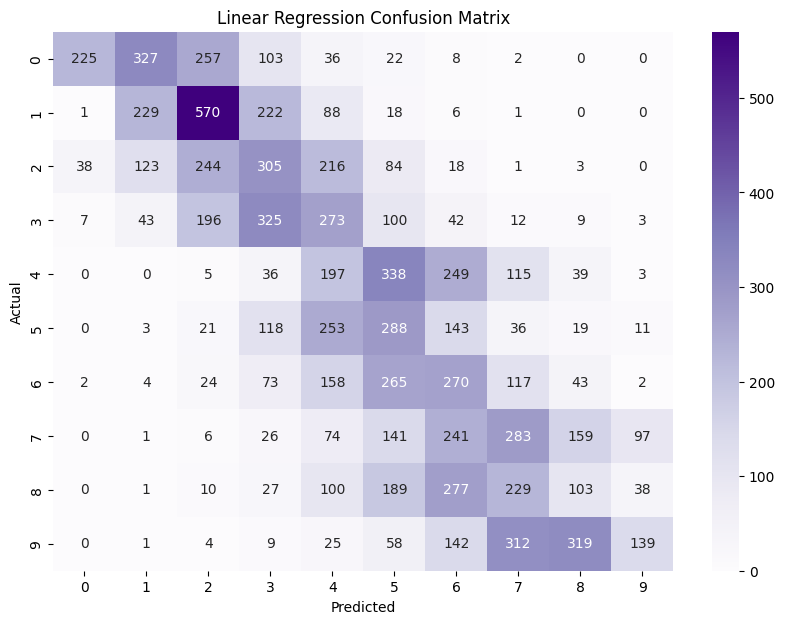

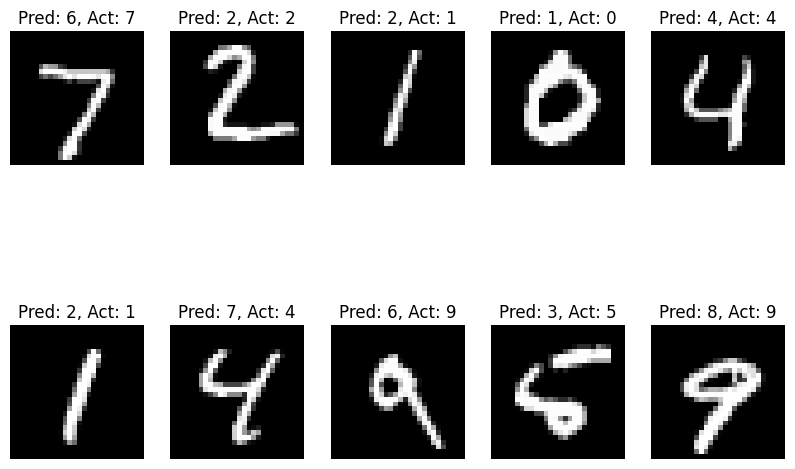

In [ ]:
# Create LR Model
LR = LinearRegression()

# Train the model
LR.fit(x_train, y_train)
# Predict
y_pred_continuous = LR.predict(x_test)

# Convert predictions to nearest integer (0–9)
y_pred = np.round(y_pred_continuous).astype(int)

# Clip predictions to stay in valid digit range
y_pred = np.clip(y_pred, 0, 9)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("LR Accuracy:", accuracy)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

# Classification Report
report = classification_report(y_test, y_pred)
print("\nClassification Report:\n", report)

# Evaluate the model using Mean Squared Error (MSE) and R-squared (R²)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Print evaluation metrics
print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

# Visualize Confusion Matrix
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
plt.title('Linear Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

plt.figure(figsize=(10, 7))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title(f"Pred: {y_pred[i]}, Act: {y_test[i]}")
    plt.axis('off')
plt.show()

# ✅ K-means Model

K-means Accuracy: 0.5846

Confusion Matrix:
 [[ 781    5    4   57   14    0   41    2   74    2]
 [   0 1129    0    3    0    0    2    0    1    0]
 [  13  136  709   76   34    0   20   11   24    9]
 [   4   63   38  685    7    0    9    8  178   18]
 [   0   42    3    0  366    0   23  249    2  297]
 [   6  111    4  297   28    0   23   57  316   50]
 [  16   43    8    1  125    0  737    0   26    2]
 [   1   84   11    0   76    0    1  425    1  429]
 [   7   80    6  250   18    0   10   34  525   44]
 [   7   23    2    7  225    0    2  241   13  489]]

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.80      0.86       980
           1       0.66      0.99      0.79      1135
           2       0.90      0.69      0.78      1032
           3       0.50      0.68      0.57      1010
           4       0.41      0.37      0.39       982
           5       1.00      0.00      0.00       892
           6       0

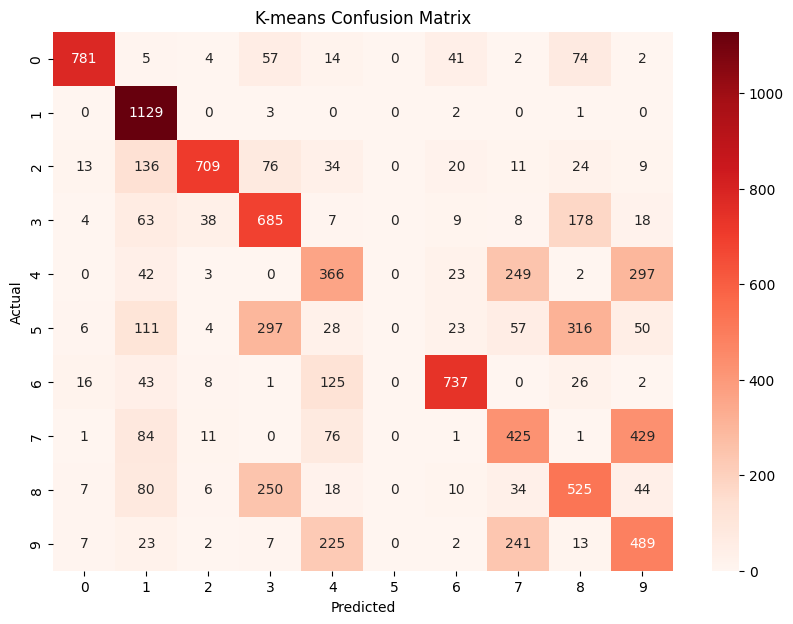

In [ ]:
# Create K-means model
kmeans = KMeans(n_clusters=10, random_state=42)

# Train the model
kmeans.fit(x_train)

# Predict clusters on test data
y_pred = kmeans.predict(x_test)

cluster_labels = np.zeros(10)

for i in range(10):
    cluster_labels[i] = mode(y_train[kmeans.labels_ == i])[0]

# Assign the most frequent digit in each cluster to the predictions
y_pred_final = np.array([cluster_labels[label] for label in y_pred])

# Accuracy
accuracy = accuracy_score(y_test, y_pred_final)
print("K-means Accuracy:", accuracy)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_final)
print("\nConfusion Matrix:\n", cm)

# Classification Report
report = classification_report(y_test, y_pred_final, zero_division=1)
print("\nClassification Report:\n", report)

# Visualize Confusion Matrix
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
plt.title('K-means Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Results Comparison Table

In [ ]:
data = {
    "Model": ["K-Nearest Neighbors (KNN)", "Support Vector Machine (SVM)", "Linear Regression (LR)", "K-means"],
    "Accuracy": ["96.88%", "94.04%", "23.03%", "58.46%"],
    "Precision": [0.97, 0.94, 0.30, 0.65],
    "Recall": [0.97, 0.94, 0.23, 0.57],
    "F1-Score": [0.97, 0.94, 0.23, 0.55]
}

# Create a DataFrame from the dictionary
df_results = pd.DataFrame(data)

# Display the table
df_results

,Model,Accuracy,Precision,Recall,F1-Score
0,K-Nearest Neighbors (KNN),96.88%,0.97,0.97,0.97
1,Support Vector Machine (SVM),94.04%,0.94,0.94,0.94
2,Linear Regression (LR),23.03%,0.30,0.23,0.23
3,K-means,58.46%,0.65,0.57,0.55
